for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set total length is :  236664
看看使用了全体数据的均值还是训练数据
236664
结束》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》》
mean is:  0.000877445154967278
std is  3.855830028757664
oversampling thresholds are:  -0.2466077208518982 0.20206351578235626
norm is:  [8.77445155e-04 3.85583003e+00]
Begin to generate val_dataloader!
Validation DATA shape,  (60, 360, 3)
Validation Label,  (60, 72, 3)
val set saved to :  ./output/Almaden/val/validation_timestamps_24avg.tsv
Begin to generate train_dataloader!
Train DATA shape,  (56000, 360, 3)
Train Label,  (56000, 72, 3)
训练集数据的选取长度是：  56000
训练集标签的选取长度是：  56000
[Route Quantiles] q50=2.849976, q80=5.970837, q95=19.300018
route_labels shape: (56000,)
route label counts: [44800 11200]
刷新数据集********************
for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set total length is :  236664
[TEST] 构建测试集...
刷新数据集********************
for sensor  reservoir_stor_4001_sof24 start_num is:  155567
train set to

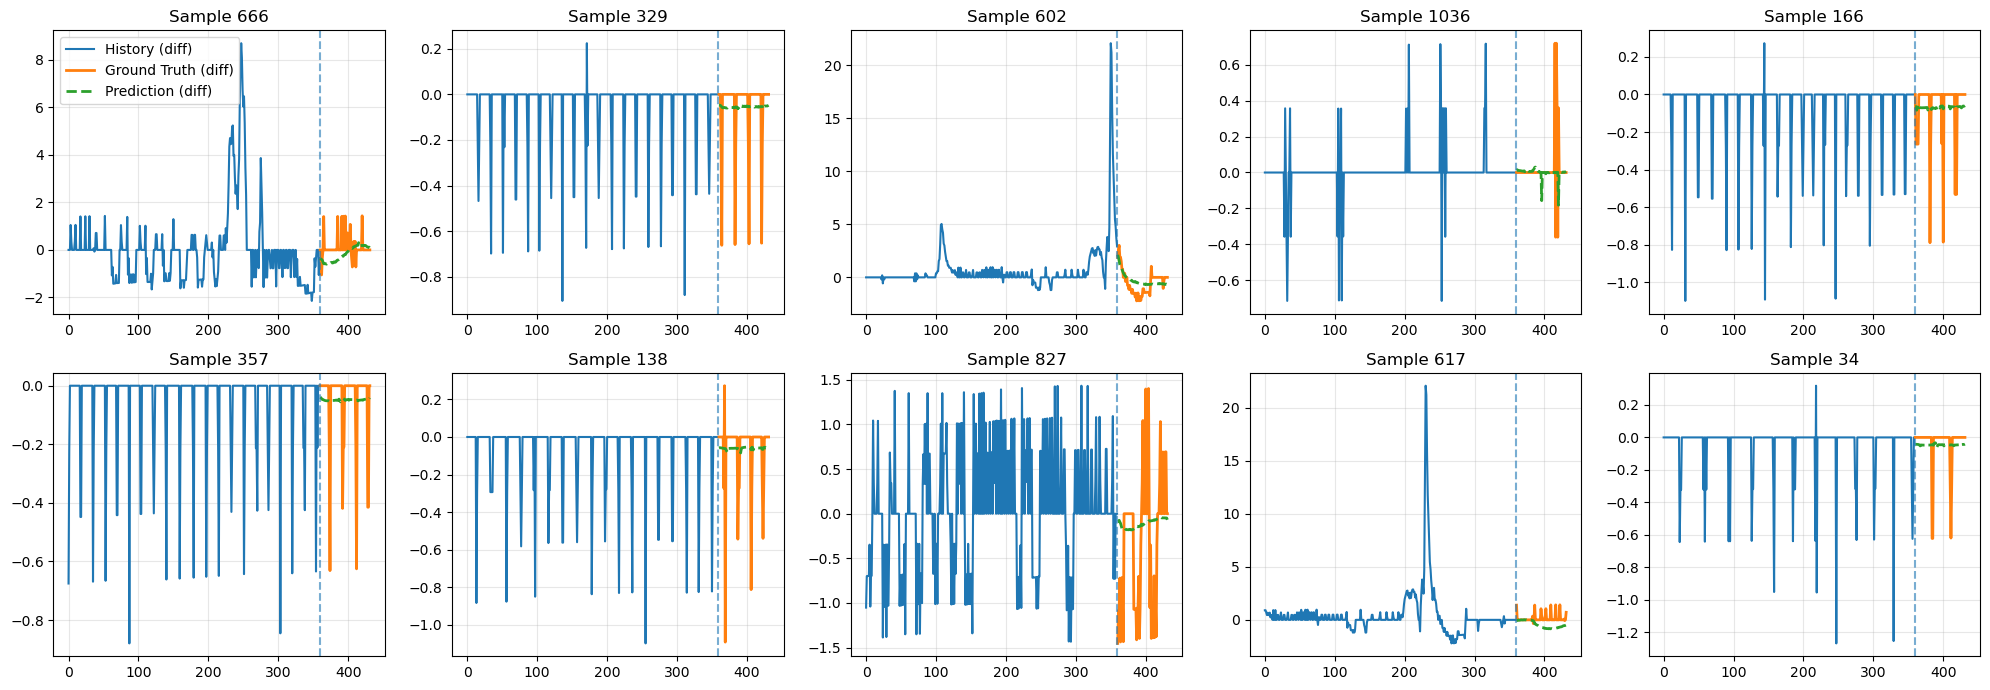

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import random

# ========= 1) 改成你项目里的真实模块路径 =========
from configs.ExtremeLSTMMemoConfig import ExtremeLSTMMemoConfig
from data_provider.DS3 import DS
from exp.exp_model import Model

# ========= 2) 初始化 config / data / model =========
config = ExtremeLSTMMemoConfig()
config.mode = "train"   # DS 在 mode='train' 时会自动构建 train/val/test loader
config.device = "cuda" if torch.cuda.is_available() else "cpu"
config.d_model = 128  # 必须和 checkpoint 一致
config.pred_len = 72  # 必须和 checkpoint 一致

# ========= 3) 读取你训练时用的原始数据 =========
# 这里的 trainX 必须是一个 DataFrame，并且至少包含:
# ['datetime', 'value']
trainX = pd.read_csv(
    "./datasets/" + config.dataset + "/" + config.reservoir_sensor + ".tsv", sep="\t"
)
trainX.columns = ["datetime", "value"]
trainX.sort_values("datetime", inplace=True)

datamodule = DS(config, trainX)
model = Model(config)

# ========= 4) 加载权重 =========
ckpt_path = "./checkpoints/extreme_lstm_memo/Datasetwater_batchsize256_Modelextreme_lstm_memo_dmodel128_reservoirreservoir_stor_4001_sof24_epochs200_patience40_dropout0.3_SeqLen360_PredLen72_round_0.pt"
state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
model.load_state_dict(state, strict=False)
model.to(config.device)
model.eval()

# ========= 5) 构建 retrieval index（和你正式 test 更一致） =========
try:
    model.prepare_retrieval_index(
        datamodule.train_data_loader.dataset,
        datamodule.train_data_loader
    )
except Exception as e:
    print("skip retrieval index:", e)

# ========= 6) 跑完整个 test set，并保存差分序列 =========
all_hist_diff = []
all_pred_diff = []
all_real_diff = []

with torch.no_grad():
    for batch in datamodule.test_data_loader:
        x, x_mark, label, sample_ids, route_labels = batch

        x = x.to(config.device)
        x_mark = x_mark.to(config.device)
        label = label.to(config.device)
        sample_ids = sample_ids.to(config.device).long()

        # 这里直接使用模型输出空间里的差分值，不做任何反归一化
        hist_diff = x[:, :, 0]

        dec_input = torch.zeros_like(label[:, -config.pred_len:, :]).float()
        dec_input = torch.cat(
            [label[:, :config.label_len, :], dec_input],
            dim=1
        ).float().to(config.device)

        output, _ = model(
            x,
            x_mark,
            dec_input=dec_input,
            sample_ids=sample_ids,
            route_labels=None,
            mode="test"
        )

        pred_diff = output["point_pred"][:, :, 0]
        real_diff = label[:, -config.pred_len:, 0]

        all_hist_diff.append(hist_diff.detach().cpu())
        all_pred_diff.append(pred_diff.detach().cpu())
        all_real_diff.append(real_diff.detach().cpu())

all_hist_diff = torch.cat(all_hist_diff, dim=0)
all_pred_diff = torch.cat(all_pred_diff, dim=0)
all_real_diff = torch.cat(all_real_diff, dim=0)

# ========= 7) 从整个 test set 随机抽 10 个样本，画“历史差分 + 未来差分” =========
num_show = 10
total_num = all_pred_diff.shape[0]
chosen_idx = random.sample(range(total_num), k=min(num_show, total_num))

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for ax, sample_idx in zip(axes, chosen_idx):
    hist_curve = all_hist_diff[sample_idx].numpy().squeeze()
    pred_curve = all_pred_diff[sample_idx].numpy().squeeze()
    real_curve = all_real_diff[sample_idx].numpy().squeeze()

    hist_x = range(len(hist_curve))
    fut_x = range(len(hist_curve), len(hist_curve) + len(real_curve))

    ax.plot(hist_x, hist_curve, label="History (diff)")
    ax.plot(fut_x, real_curve, label="Ground Truth (diff)", linewidth=2)
    ax.plot(fut_x, pred_curve, label="Prediction (diff)", linestyle="--", linewidth=2)

    ax.axvline(x=len(hist_curve) - 1, linestyle="--", alpha=0.6)
    ax.set_title(f"Sample {sample_idx}")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()